# SupportOps AI - DistilBERT Intent Classification

## Objective

Fine-tune a pretrained DistilBERT Transformer model for
77-class customer-support intent classification using BANKING77.

## Model Comparison

Classical Baseline:
TF-IDF + Logistic Regression

Transformer:
DistilBERT

## Evaluation

- Accuracy
- Macro Precision
- Macro Recall
- Macro F1
- Per-intent F1
- Error Analysis
- Official BANKING77 Test Set
- Strict Zero-Overlap Test Set

In [1]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("Libraries imported successfully!")

Libraries imported successfully!


Check PyTorch device inside notebook

In [2]:
print("PyTorch version:", torch.__version__)

print(
    "MPS available:",
    torch.backends.mps.is_available()
)

PyTorch version: 2.13.0
MPS available: True


In [3]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)

Using device: mps


Load BANKING77

In [4]:
TRAIN_PATH = "../data/raw/banking77_train.csv"
TEST_PATH = "../data/raw/banking77_test.csv"

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

train_df = train_df[
    ["text", "intent"]
].copy()

test_df = test_df[
    ["text", "intent"]
].copy()

print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)

train_df.head()

Training shape: (10003, 2)
Testing shape: (3080, 2)


,text,intent
0,I am still waiting on my card?,card_arrival
1,What can I do if my card still hasn't arrived ...,card_arrival
2,I have been waiting over a week. Is the card s...,card_arrival
3,Can I track my card while it is in the process...,card_arrival
4,"How do I know if I will get my card, or if it ...",card_arrival


Create train/validation sets

In [5]:
train_data, val_data = train_test_split(
    train_df,
    test_size=0.15,
    random_state=42,
    stratify=train_df["intent"]
)

print("Training subset:", len(train_data))
print("Validation subset:", len(val_data))
print("Official test:", len(test_df))

Training subset: 8502
Validation subset: 1501
Official test: 3080


Convert labels into numbers

In [6]:
intent_names = sorted(
    train_df["intent"].unique()
)

print("Number of intents:", len(intent_names))

Number of intents: 77


In [7]:
#Create mappings
label2id = {
    intent: idx
    for idx, intent in enumerate(intent_names)
}

id2label = {
    idx: intent
    for intent, idx in label2id.items()
}

In [8]:
list(label2id.items())[:10]

[('Refund_not_showing_up', 0),
 ('activate_my_card', 1),
 ('age_limit', 2),
 ('apple_pay_or_google_pay', 3),
 ('atm_support', 4),
 ('automatic_top_up', 5),
 ('balance_not_updated_after_bank_transfer', 6),
 ('balance_not_updated_after_cheque_or_cash_deposit', 7),
 ('beneficiary_not_allowed', 8),
 ('cancel_transfer', 9)]

Add numeric labels

In [9]:
train_data = train_data.copy()
val_data = val_data.copy()
test_data = test_df.copy()

train_data["label"] = (
    train_data["intent"].map(label2id)
)

val_data["label"] = (
    val_data["intent"].map(label2id)
)

test_data["label"] = (
    test_data["intent"].map(label2id)
)

In [10]:
train_data[
    ["text", "intent", "label"]
].head()

,text,intent,label
6898,Where can I update my pin number?,change_pin,22
2067,What is the reason that my top-up is still pen...,pending_top_up,48
8168,Can I use my virtual card to complete transact...,virtual_card_not_working,72
975,What fiat currencies are used for holdings?,fiat_currency_support,37
9665,"Apple watch top up help, please?",apple_pay_or_google_pay,3


Load the tokenizer

In [11]:
MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

print("Tokenizer loaded successfully!")

Tokenizer loaded successfully!


See tokenization

In [12]:
sample_text = (
    "I was charged twice for the same card payment."
)

tokens = tokenizer.tokenize(
    sample_text
)

print(tokens)

['i', 'was', 'charged', 'twice', 'for', 'the', 'same', 'card', 'payment', '.']


In [13]:
token_ids = tokenizer.convert_tokens_to_ids(
    tokens
)

print(token_ids)

[1045, 2001, 5338, 3807, 2005, 1996, 2168, 4003, 7909, 1012]


Special tokens

In [14]:
encoded = tokenizer(
    sample_text
)

encoded

{'input_ids': [101, 1045, 2001, 5338, 3807, 2005, 1996, 2168, 4003, 7909, 1012, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

Decode the Id's

In [15]:
tokenizer.convert_ids_to_tokens(
    encoded["input_ids"]
)

['[CLS]',
 'i',
 'was',
 'charged',
 'twice',
 'for',
 'the',
 'same',
 'card',
 'payment',
 '.',
 '[SEP]']

In [16]:
token_lengths = []

for text in train_df["text"]:
    
    encoded = tokenizer(
        text,
        add_special_tokens=True,
        truncation=False
    )
    
    token_lengths.append(
        len(encoded["input_ids"])
    )

In [17]:
token_length_series = pd.Series(
    token_lengths
)

token_length_series.describe(
    percentiles=[
        0.90,
        0.95,
        0.99
    ]
)

count    10003.000000
mean        16.213736
std          9.218455
min          4.000000
90%         28.000000
95%         37.000000
99%         53.000000
max         98.000000
dtype: float64

Plot token lengths

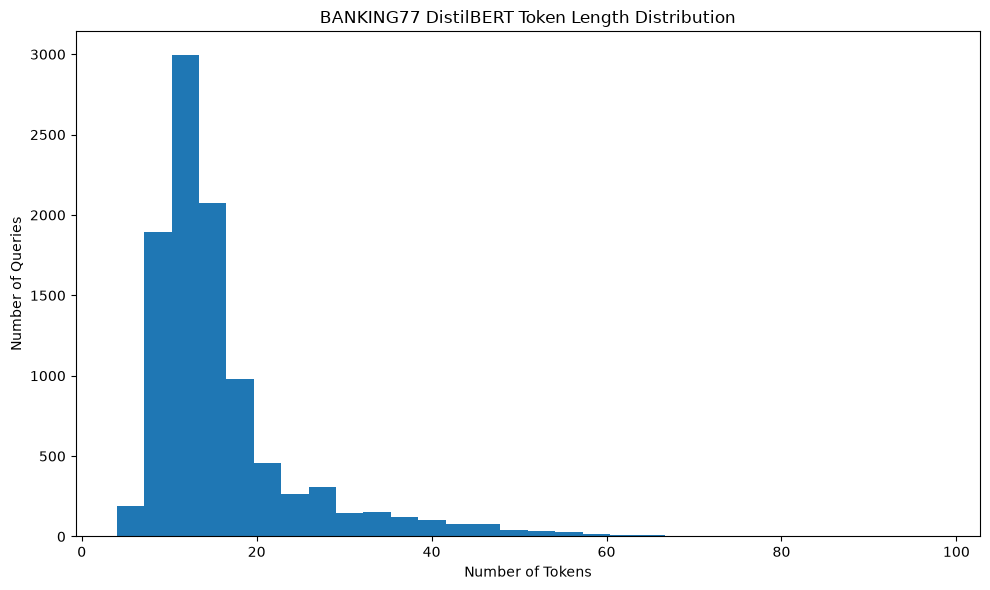

In [18]:
plt.figure(figsize=(10, 6))

plt.hist(
    token_lengths,
    bins=30
)

plt.title(
    "BANKING77 DistilBERT Token Length Distribution"
)

plt.xlabel(
    "Number of Tokens"
)

plt.ylabel(
    "Number of Queries"
)

plt.tight_layout()
plt.show()

Tokenize the datasets

In [19]:
MAX_LENGTH = 64

In [20]:
sample_encoding = tokenizer(
    "I was charged twice for the same card payment.",
    max_length=MAX_LENGTH,
    padding="max_length",
    truncation=True,
    return_tensors="pt"
)

sample_encoding

{'input_ids': tensor([[ 101, 1045, 2001, 5338, 3807, 2005, 1996, 2168, 4003, 7909, 1012,  102,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])}

In [21]:
print(
    "Input IDs shape:",
    sample_encoding["input_ids"].shape
)

print(
    "Attention mask shape:",
    sample_encoding["attention_mask"].shape
)

Input IDs shape: torch.Size([1, 64])
Attention mask shape: torch.Size([1, 64])


Understand padding

In [22]:
print(
    tokenizer.convert_ids_to_tokens(
        sample_encoding["input_ids"][0]
    )
)

['[CLS]', 'i', 'was', 'charged', 'twice', 'for', 'the', 'same', 'card', 'payment', '.', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']


In [23]:
print(
    sample_encoding["attention_mask"][0]
)

tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])


Create a PyTorch Dataset

In [24]:
from torch.utils.data import Dataset

In [25]:
class Banking77Dataset(Dataset):

    def __init__(
        self,
        texts,
        labels,
        tokenizer,
        max_length
    ):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):

        text = self.texts[index]
        label = self.labels[index]

        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        return {
            "input_ids":
                encoding["input_ids"].squeeze(0),

            "attention_mask":
                encoding["attention_mask"].squeeze(0),

            "labels":
                torch.tensor(
                    label,
                    dtype=torch.long
                )
        }

Create train, validation and test datasets

In [26]:
train_dataset = Banking77Dataset(
    train_data["text"],
    train_data["label"],
    tokenizer,
    MAX_LENGTH
)

val_dataset = Banking77Dataset(
    val_data["text"],
    val_data["label"],
    tokenizer,
    MAX_LENGTH
)

test_dataset = Banking77Dataset(
    test_data["text"],
    test_data["label"],
    tokenizer,
    MAX_LENGTH
)

In [27]:
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 8502
Validation: 1501
Test: 3080


Inspect one encoded example

In [28]:
example = train_dataset[0]

print(
    "Input IDs shape:",
    example["input_ids"].shape
)

print(
    "Attention mask shape:",
    example["attention_mask"].shape
)

print(
    "Label:",
    example["labels"]
)

Input IDs shape: torch.Size([64])
Attention mask shape: torch.Size([64])
Label: tensor(22)


In [29]:
print(
    tokenizer.decode(
        example["input_ids"],
        skip_special_tokens=True
    )
)

where can i update my pin number?


In [30]:
print(
    "Intent:",
    id2label[
        example["labels"].item()
    ]
)

Intent: change_pin


Load pretrained DistilBERT

In [31]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=77,
    id2label=id2label,
    label2id=label2id
)

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Move model to your device

In [32]:
model = model.to(device)

print(
    "Model loaded on:",
    device
)

Model loaded on: mps


Import Trainer components

In [33]:
from transformers import (
    Trainer,
    TrainingArguments
)

print("Trainer components imported!")

Trainer components imported!


Create the evaluation function

In [34]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    # Some transformer models can return predictions as tuples
    if isinstance(logits, tuple):
        logits = logits[0]

    predictions = np.argmax(
        logits,
        axis=-1
    )

    accuracy = accuracy_score(
        labels,
        predictions
    )

    precision = precision_score(
        labels,
        predictions,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        labels,
        predictions,
        average="macro",
        zero_division=0
    )

    f1 = f1_score(
        labels,
        predictions,
        average="macro",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1
    }

Training configuration

In [36]:
import transformers

print(transformers.__version__)

5.15.1


In [37]:
training_args = TrainingArguments(

    # Where checkpoints are stored
    output_dir="../ml/artifacts/distilbert_checkpoints",

    # Fine-tuning learning rate
    learning_rate=2e-5,

    # Batch sizes
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,

    # Number of training epochs
    num_train_epochs=3,

    # Regularization
    weight_decay=0.01,

    # 10% of total training steps used for warmup
    warmup_steps=0.10,

    # Evaluate after every epoch
    eval_strategy="epoch",

    # Save after every epoch
    save_strategy="epoch",

    # Keep only two checkpoints
    save_total_limit=2,

    # Automatically restore best checkpoint
    load_best_model_at_end=True,

    # Select best model using validation Macro F1
    metric_for_best_model="f1_macro",
    greater_is_better=True,

    # Training logs
    logging_strategy="steps",
    logging_steps=50,

    # No WandB / external tracker for now
    report_to="none",

    # Better compatibility with macOS/MPS
    dataloader_num_workers=0,
    dataloader_pin_memory=False,

    # Reproducibility
    seed=42
)

print("Training configuration created successfully!")

Training configuration created successfully!


Create the Trainer

In [38]:
trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=train_dataset,
    eval_dataset=val_dataset,

    compute_metrics=compute_metrics
)

print("Trainer created successfully!")

Trainer created successfully!


Confirm the device

In [39]:
print(
    "Trainer device:",
    trainer.args.device
)

Trainer device: mps


Start fine tuning

In [40]:
train_result = trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,2.511370,2.184589,0.665556,0.647435,0.624676,0.592097
2,1.358144,1.198016,0.812791,0.787336,0.777069,0.764474
3,1.033467,0.968792,0.844770,0.850101,0.818056,0.812861


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Evaluate the best validation model

In [41]:
validation_results = trainer.evaluate(
    val_dataset
)

validation_results

Training Loss,Validation Loss,Epoch,Accuracy,Precision Macro,Recall Macro,F1 Macro
1.033467,0.968792,3,0.844770,0.850101,0.818056,0.812861


{'eval_loss': 0.968791663646698,
 'eval_accuracy': 0.8447701532311792,
 'eval_precision_macro': 0.850100600843405,
 'eval_recall_macro': 0.8180563488484752,
 'eval_f1_macro': 0.812861492067468}

In [42]:
print("VALIDATION RESULTS")
print("=" * 50)

print(
    f"Accuracy: "
    f"{validation_results['eval_accuracy']:.4f}"
)

print(
    f"Macro Precision: "
    f"{validation_results['eval_precision_macro']:.4f}"
)

print(
    f"Macro Recall: "
    f"{validation_results['eval_recall_macro']:.4f}"
)

print(
    f"Macro F1: "
    f"{validation_results['eval_f1_macro']:.4f}"
)

print(
    f"Loss: "
    f"{validation_results['eval_loss']:.4f}"
)

VALIDATION RESULTS
Accuracy: 0.8448
Macro Precision: 0.8501
Macro Recall: 0.8181
Macro F1: 0.8129
Loss: 0.9688


Inspect the training history

In [43]:
log_history = pd.DataFrame(
    trainer.state.log_history
)

log_history.tail(20)

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_precision_macro,eval_recall_macro,eval_f1_macro,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
16,1.695613,6.267497,1.110028e-05,1.503759,800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17,1.600033,6.184829,1.040390e-05,1.597744,850,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18,1.530636,5.627533,9.707521e-06,1.691729,900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19,1.425029,8.192514,9.011142e-06,1.785714,950,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20,1.355732,7.371317,8.314763e-06,1.879699,1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21,1.358144,6.048820,7.618384e-06,1.973684,1050,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
22,NaN,NaN,NaN,2.000000,1064,1.198016,0.812791,0.787336,0.777069,0.764474,46.2125,32.480,1.017,NaN,NaN,NaN,NaN,NaN
23,1.196223,5.287600,6.922006e-06,2.067669,1100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24,1.175697,5.034288,6.225627e-06,2.161654,1150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25,1.180288,7.529550,5.529248e-06,2.255639,1200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Plot training loss

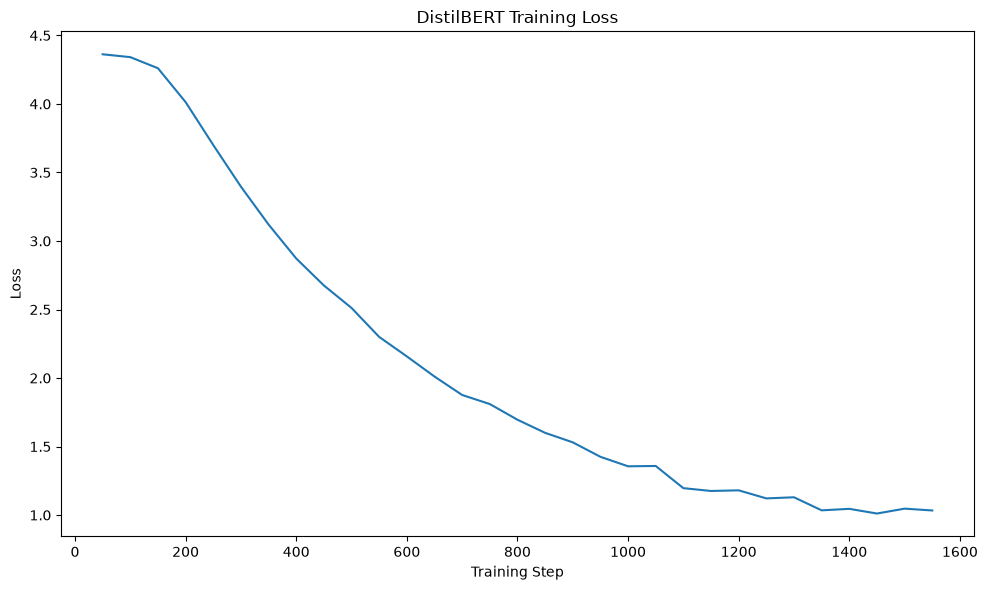

In [44]:
training_logs = log_history[
    log_history["loss"].notna()
].copy()

plt.figure(figsize=(10, 6))

plt.plot(
    training_logs["step"],
    training_logs["loss"]
)

plt.title(
    "DistilBERT Training Loss"
)

plt.xlabel("Training Step")
plt.ylabel("Loss")

plt.tight_layout()
plt.show()

Plot validation Macro F1

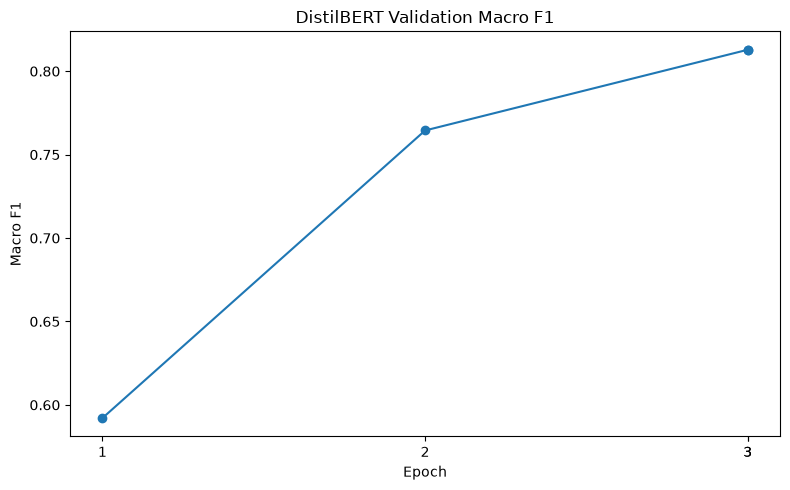

In [45]:
evaluation_logs = log_history[
    log_history["eval_f1_macro"].notna()
].copy()

plt.figure(figsize=(8, 5))

plt.plot(
    evaluation_logs["epoch"],
    evaluation_logs["eval_f1_macro"],
    marker="o"
)

plt.title(
    "DistilBERT Validation Macro F1"
)

plt.xlabel("Epoch")
plt.ylabel("Macro F1")

plt.xticks(
    evaluation_logs["epoch"]
)

plt.tight_layout()
plt.show()

Plot validation loss

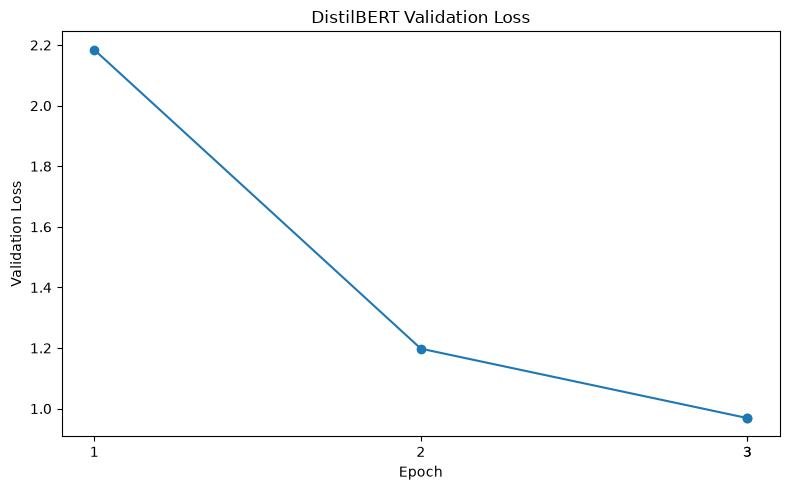

In [46]:
plt.figure(figsize=(8, 5))

plt.plot(
    evaluation_logs["epoch"],
    evaluation_logs["eval_loss"],
    marker="o"
)

plt.title(
    "DistilBERT Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")

plt.xticks(
    evaluation_logs["epoch"]
)

plt.tight_layout()
plt.show()

Check which checkpoint won

In [47]:
print(
    "Best checkpoint:",
    trainer.state.best_model_checkpoint
)

print(
    "Best validation metric:",
    trainer.state.best_metric
)

Best checkpoint: ../ml/artifacts/distilbert_checkpoints/checkpoint-1596
Best validation metric: 0.812861492067468


##Final DistilBERT Test Evaluation
##Evaluate the official BANKING77 test set

In [48]:
official_test_output = trainer.predict(
    test_dataset
)

official_logits = official_test_output.predictions
official_labels = official_test_output.label_ids

official_predictions = np.argmax(
    official_logits,
    axis=-1
)

In [49]:
distilbert_official_accuracy = accuracy_score(
    official_labels,
    official_predictions
)

distilbert_official_precision = precision_score(
    official_labels,
    official_predictions,
    average="macro",
    zero_division=0
)

distilbert_official_recall = recall_score(
    official_labels,
    official_predictions,
    average="macro",
    zero_division=0
)

distilbert_official_f1 = f1_score(
    official_labels,
    official_predictions,
    average="macro",
    zero_division=0
)

print("DISTILBERT — OFFICIAL BANKING77 TEST")
print("=" * 55)

print(
    f"Accuracy:        {distilbert_official_accuracy:.4f}"
)

print(
    f"Macro Precision: {distilbert_official_precision:.4f}"
)

print(
    f"Macro Recall:    {distilbert_official_recall:.4f}"
)

print(
    f"Macro F1:        {distilbert_official_f1:.4f}"
)

DISTILBERT — OFFICIAL BANKING77 TEST
Accuracy:        0.8159
Macro Precision: 0.8166
Macro Recall:    0.8159
Macro F1:        0.7975


Recreate the strict test set

In [50]:
def normalize_text(text):
    return " ".join(
        str(text)
        .lower()
        .strip()
        .split()
    )

In [51]:
train_normalized_texts = set(
    train_df["text"].apply(normalize_text)
)

strict_test_data = test_df[
    ~test_df["text"]
    .apply(normalize_text)
    .isin(train_normalized_texts)
].copy()

print("Official test size:", len(test_df))
print("Strict test size:", len(strict_test_data))

Official test size: 3080
Strict test size: 3073


In [52]:
strict_test_data["label"] = (
    strict_test_data["intent"]
    .map(label2id)
)

Create the strict PyTorch dataset

In [53]:
strict_test_dataset = Banking77Dataset(
    strict_test_data["text"],
    strict_test_data["label"],
    tokenizer,
    MAX_LENGTH
)

In [54]:
print(
    "Strict test examples:",
    len(strict_test_dataset)
)

Strict test examples: 3073


Evaluate DistilBERT on strict test data

In [55]:
strict_test_output = trainer.predict(
    strict_test_dataset
)

strict_logits = (
    strict_test_output.predictions
)

strict_labels = (
    strict_test_output.label_ids
)

strict_predictions = np.argmax(
    strict_logits,
    axis=-1
)

In [56]:
distilbert_strict_accuracy = accuracy_score(
    strict_labels,
    strict_predictions
)

distilbert_strict_precision = precision_score(
    strict_labels,
    strict_predictions,
    average="macro",
    zero_division=0
)

distilbert_strict_recall = recall_score(
    strict_labels,
    strict_predictions,
    average="macro",
    zero_division=0
)

distilbert_strict_f1 = f1_score(
    strict_labels,
    strict_predictions,
    average="macro",
    zero_division=0
)

print("DISTILBERT — STRICT ZERO-OVERLAP TEST")
print("=" * 55)

print(
    f"Accuracy:        {distilbert_strict_accuracy:.4f}"
)

print(
    f"Macro Precision: {distilbert_strict_precision:.4f}"
)

print(
    f"Macro Recall:    {distilbert_strict_recall:.4f}"
)

print(
    f"Macro F1:        {distilbert_strict_f1:.4f}"
)

DISTILBERT — STRICT ZERO-OVERLAP TEST
Accuracy:        0.8161
Macro Precision: 0.8166
Macro Recall:    0.8156
Macro F1:        0.7975


Compare DistilBERT against TF-IDF

In [57]:
model_comparison = pd.DataFrame({
    "Model": [
        "TF-IDF + Logistic Regression",
        "DistilBERT"
    ],

    "Official Accuracy": [
        0.8588,
        distilbert_official_accuracy
    ],

    "Official Macro F1": [
        0.8581,
        distilbert_official_f1
    ],

    "Strict Accuracy": [
        0.8584,
        distilbert_strict_accuracy
    ],

    "Strict Macro F1": [
        0.8576,
        distilbert_strict_f1
    ]
})

model_comparison

,Model,Official Accuracy,Official Macro F1,Strict Accuracy,Strict Macro F1
0,TF-IDF + Logistic Regression,0.858800,0.858100,0.858400,0.857600
1,DistilBERT,0.815909,0.797546,0.816141,0.797467


Error analysis for DistilBERT

In [58]:
actual_intents = [
    id2label[int(label)]
    for label in official_labels
]

predicted_intents = [
    id2label[int(pred)]
    for pred in official_predictions
]

In [59]:
distilbert_results_df = pd.DataFrame({
    "text": test_data["text"].values,
    "actual": actual_intents,
    "predicted": predicted_intents
})

In [60]:
distilbert_errors = (
    distilbert_results_df[
        distilbert_results_df["actual"]
        != distilbert_results_df["predicted"]
    ]
    .copy()
)

print(
    "Correct predictions:",
    len(distilbert_results_df)
    - len(distilbert_errors)
)

print(
    "Incorrect predictions:",
    len(distilbert_errors)
)

Correct predictions: 2513
Incorrect predictions: 567


Find Transformer confusion pairs

In [61]:
distilbert_confusions = (
    distilbert_errors
    .groupby(
        ["actual", "predicted"]
    )
    .size()
    .reset_index(
        name="count"
    )
    .sort_values(
        "count",
        ascending=False
    )
)

distilbert_confusions.head(20)

,actual,predicted,count
54,card_swallowed,declined_cash_withdrawal,32
27,card_acceptance,order_physical_card,29
212,verify_my_identity,why_verify_identity,20
68,contactless_not_working,activate_my_card,19
216,virtual_card_not_working,getting_virtual_card,19
215,virtual_card_not_working,get_disposable_virtual_card,17
32,card_delivery_estimate,card_arrival,9
113,get_disposable_virtual_card,disposable_card_limits,7
82,declined_transfer,declined_card_payment,7
61,change_pin,get_physical_card,7


Inspect wrong predictions manually

In [62]:
for _, row in (
    distilbert_errors.head(10).iterrows()
):

    print("=" * 80)

    print("CUSTOMER QUERY:")
    print(row["text"])

    print("\nACTUAL:")
    print(row["actual"])

    print("\nPREDICTED:")
    print(row["predicted"])

    print()

CUSTOMER QUERY:
When will I get my card?

ACTUAL:
card_arrival

PREDICTED:
card_delivery_estimate

CUSTOMER QUERY:
Is there tracking info available?

ACTUAL:
card_arrival

PREDICTED:
why_verify_identity

CUSTOMER QUERY:
How do I add the card to my account?

ACTUAL:
card_linking

PREDICTED:
order_physical_card

CUSTOMER QUERY:
The app doesn't show the card I received.

ACTUAL:
card_linking

PREDICTED:
card_arrival

CUSTOMER QUERY:
Is it a good time to exchange?

ACTUAL:
exchange_rate

PREDICTED:
exchange_via_app

CUSTOMER QUERY:
when does the rate get determined

ACTUAL:
exchange_rate

PREDICTED:
card_payment_wrong_exchange_rate

CUSTOMER QUERY:
I made a currency exchange and think I was charged more than I should of been.

ACTUAL:
card_payment_wrong_exchange_rate

PREDICTED:
exchange_charge

CUSTOMER QUERY:
Why am I being charged more ?

ACTUAL:
card_payment_wrong_exchange_rate

PREDICTED:
card_payment_fee_charged

CUSTOMER QUERY:
the conversion value for my card payments is incorrect.

Find per-intent performance

In [63]:
distilbert_report = classification_report(
    actual_intents,
    predicted_intents,
    output_dict=True,
    zero_division=0
)

distilbert_report_df = (
    pd.DataFrame(
        distilbert_report
    )
    .transpose()
)

In [65]:
#isolate only the 77 intents
intent_report = (
    distilbert_report_df.loc[
        intent_names
    ]
)

In [66]:
#worst 10
intent_report.sort_values(
    "f1-score"
).head(10)[
    [
        "precision",
        "recall",
        "f1-score",
        "support"
    ]
]

,precision,recall,f1-score,support
virtual_card_not_working,0.000000,0.000,0.000000,40.0
card_acceptance,0.000000,0.000,0.000000,40.0
topping_up_by_card,0.250000,0.025,0.045455,40.0
card_swallowed,1.000000,0.025,0.048780,40.0
contactless_not_working,1.000000,0.300,0.461538,40.0
order_physical_card,0.436620,0.775,0.558559,40.0
verify_my_identity,0.826087,0.475,0.603175,40.0
get_disposable_virtual_card,0.551020,0.675,0.606742,40.0
declined_cash_withdrawal,0.448276,0.975,0.614173,40.0
why_verify_identity,0.550000,0.825,0.660000,40.0


In [67]:
#best 10
intent_report.sort_values(
    "f1-score",
    ascending=False
).head(10)[
    [
        "precision",
        "recall",
        "f1-score",
        "support"
    ]
]

,precision,recall,f1-score,support
apple_pay_or_google_pay,1.000000,1.000,1.000000,40.0
verify_top_up,1.000000,1.000,1.000000,40.0
passcode_forgotten,0.975610,1.000,0.987654,40.0
edit_personal_details,0.930233,1.000,0.963855,40.0
verify_source_of_funds,0.930233,1.000,0.963855,40.0
card_about_to_expire,0.974359,0.950,0.962025,40.0
age_limit,0.909091,1.000,0.952381,40.0
atm_support,1.000000,0.900,0.947368,40.0
automatic_top_up,1.000000,0.900,0.947368,40.0
balance_not_updated_after_cheque_or_cash_deposit,0.906977,0.975,0.939759,40.0


reload a fresh pretrained model

In [68]:
model_5epoch = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=77,
    id2label=id2label,
    label2id=label2id
)

model_5epoch = model_5epoch.to(device)

print("Fresh DistilBERT loaded for Experiment 2")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fresh DistilBERT loaded for Experiment 2


Create separate training arguments

In [69]:
training_args_5epoch = TrainingArguments(

    output_dir="../ml/artifacts/distilbert_5epoch_checkpoints",

    learning_rate=2e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,

    # Only experimental change
    num_train_epochs=5,

    weight_decay=0.01,

    # Use the same warmup setting that worked
    # in your Experiment 1
    warmup_steps=0.10,

    eval_strategy="epoch",
    save_strategy="epoch",

    save_total_limit=2,

    load_best_model_at_end=True,

    metric_for_best_model="f1_macro",
    greater_is_better=True,

    logging_strategy="steps",
    logging_steps=50,

    report_to="none",

    dataloader_num_workers=0,
    dataloader_pin_memory=False,

    seed=42
)

Create a new Trainer

In [70]:
trainer_5epoch = Trainer(
    model=model_5epoch,
    args=training_args_5epoch,

    train_dataset=train_dataset,
    eval_dataset=val_dataset,

    compute_metrics=compute_metrics
)

print("5-epoch Trainer created")
print("Device:", trainer_5epoch.args.device)

5-epoch Trainer created
Device: mps


Start training now with 5 epochs


In [71]:
train_result_5epoch = trainer_5epoch.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,2.684895,2.329580,0.602931,0.613769,0.571234,0.530586
2,1.230982,1.049807,0.826782,0.833765,0.806997,0.804863
3,0.689462,0.629670,0.881412,0.881526,0.871508,0.871611
4,0.439006,0.490736,0.894071,0.903469,0.888378,0.890961
5,0.354080,0.454964,0.900733,0.908461,0.898258,0.899998


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Check the winning checkpoint

In [72]:
print(
    "Best checkpoint:",
    trainer_5epoch.state.best_model_checkpoint
)

print(
    "Best validation Macro F1:",
    trainer_5epoch.state.best_metric
)

Best checkpoint: ../ml/artifacts/distilbert_5epoch_checkpoints/checkpoint-2660
Best validation Macro F1: 0.8999980707852513


In [73]:
experiment_comparison = pd.DataFrame({
    "Experiment": [
        "DistilBERT - 3 epochs",
        "DistilBERT - 5 epochs"
    ],
    "Best Validation Macro F1": [
        0.812861492067468,
        trainer_5epoch.state.best_metric
    ]
})

experiment_comparison

,Experiment,Best Validation Macro F1
0,DistilBERT - 3 epochs,0.812861
1,DistilBERT - 5 epochs,0.899998


Official BANKING77 test

In [74]:
official_output_5epoch = trainer_5epoch.predict(
    test_dataset
)

official_logits_5epoch = (
    official_output_5epoch.predictions
)

official_labels_5epoch = (
    official_output_5epoch.label_ids
)

official_pred_5epoch = np.argmax(
    official_logits_5epoch,
    axis=-1
)

In [75]:
distilbert5_official_accuracy = accuracy_score(
    official_labels_5epoch,
    official_pred_5epoch
)

distilbert5_official_precision = precision_score(
    official_labels_5epoch,
    official_pred_5epoch,
    average="macro",
    zero_division=0
)

distilbert5_official_recall = recall_score(
    official_labels_5epoch,
    official_pred_5epoch,
    average="macro",
    zero_division=0
)

distilbert5_official_f1 = f1_score(
    official_labels_5epoch,
    official_pred_5epoch,
    average="macro",
    zero_division=0
)

print("DISTILBERT 5-EPOCH — OFFICIAL TEST")
print("=" * 55)

print(
    f"Accuracy:        {distilbert5_official_accuracy:.4f}"
)

print(
    f"Macro Precision: {distilbert5_official_precision:.4f}"
)

print(
    f"Macro Recall:    {distilbert5_official_recall:.4f}"
)

print(
    f"Macro F1:        {distilbert5_official_f1:.4f}"
)

DISTILBERT 5-EPOCH — OFFICIAL TEST
Accuracy:        0.9062
Macro Precision: 0.9115
Macro Recall:    0.9062
Macro F1:        0.9059


Strict zero-overlap test

In [76]:
strict_output_5epoch = trainer_5epoch.predict(
    strict_test_dataset
)

strict_logits_5epoch = (
    strict_output_5epoch.predictions
)

strict_labels_5epoch = (
    strict_output_5epoch.label_ids
)

strict_pred_5epoch = np.argmax(
    strict_logits_5epoch,
    axis=-1
)

In [77]:
distilbert5_strict_accuracy = accuracy_score(
    strict_labels_5epoch,
    strict_pred_5epoch
)

distilbert5_strict_precision = precision_score(
    strict_labels_5epoch,
    strict_pred_5epoch,
    average="macro",
    zero_division=0
)

distilbert5_strict_recall = recall_score(
    strict_labels_5epoch,
    strict_pred_5epoch,
    average="macro",
    zero_division=0
)

distilbert5_strict_f1 = f1_score(
    strict_labels_5epoch,
    strict_pred_5epoch,
    average="macro",
    zero_division=0
)

print("DISTILBERT 5-EPOCH — STRICT TEST")
print("=" * 55)

print(
    f"Accuracy:        {distilbert5_strict_accuracy:.4f}"
)

print(
    f"Macro Precision: {distilbert5_strict_precision:.4f}"
)

print(
    f"Macro Recall:    {distilbert5_strict_recall:.4f}"
)

print(
    f"Macro F1:        {distilbert5_strict_f1:.4f}"
)

DISTILBERT 5-EPOCH — STRICT TEST
Accuracy:        0.9060
Macro Precision: 0.9114
Macro Recall:    0.9059
Macro F1:        0.9057


create the important model comparison

In [78]:
comparison_df = pd.DataFrame({
    "Model": [
        "TF-IDF + Logistic Regression",
        "DistilBERT - 3 epochs",
        "DistilBERT - 5 epochs"
    ],

    "Official Accuracy": [
        0.8588,
        0.8159,
        distilbert5_official_accuracy
    ],

    "Official Macro F1": [
        0.8581,
        0.7975,
        distilbert5_official_f1
    ],

    "Strict Accuracy": [
        0.8584,
        0.8161,
        distilbert5_strict_accuracy
    ],

    "Strict Macro F1": [
        0.8576,
        0.7975,
        distilbert5_strict_f1
    ]
})

comparison_df

,Model,Official Accuracy,Official Macro F1,Strict Accuracy,Strict Macro F1
0,TF-IDF + Logistic Regression,0.858800,0.858100,0.858400,0.857600
1,DistilBERT - 3 epochs,0.815900,0.797500,0.816100,0.797500
2,DistilBERT - 5 epochs,0.906169,0.905947,0.905955,0.905695


Final Error Analysis

In [79]:
actual_intents_5epoch = [
    id2label[int(label)]
    for label in official_labels_5epoch
]

predicted_intents_5epoch = [
    id2label[int(pred)]
    for pred in official_pred_5epoch
]

distilbert5_results = pd.DataFrame({
    "text": test_data["text"].values,
    "actual": actual_intents_5epoch,
    "predicted": predicted_intents_5epoch
})

distilbert5_errors = distilbert5_results[
    distilbert5_results["actual"]
    != distilbert5_results["predicted"]
].copy()

print(
    "Total test examples:",
    len(distilbert5_results)
)

print(
    "Correct predictions:",
    len(distilbert5_results)
    - len(distilbert5_errors)
)

print(
    "Incorrect predictions:",
    len(distilbert5_errors)
)

print(
    "Error rate:",
    round(
        len(distilbert5_errors)
        / len(distilbert5_results)
        * 100,
        2
    ),
    "%"
)

Total test examples: 3080
Correct predictions: 2791
Incorrect predictions: 289
Error rate: 9.38 %


In [80]:
confusion_pairs_5epoch = (
    distilbert5_errors
    .groupby(
        ["actual", "predicted"]
    )
    .size()
    .reset_index(
        name="count"
    )
    .sort_values(
        "count",
        ascending=False
    )
)

confusion_pairs_5epoch.head(20)

,actual,predicted,count
173,why_verify_identity,verify_my_identity,13
166,virtual_card_not_working,get_disposable_virtual_card,6
57,declined_transfer,declined_card_payment,5
108,pending_transfer,balance_not_updated_after_bank_transfer,5
117,reverted_card_payment?,declined_card_payment,5
88,get_disposable_virtual_card,getting_virtual_card,5
24,card_arrival,card_delivery_estimate,4
84,fiat_currency_support,exchange_via_app,4
86,get_disposable_virtual_card,disposable_card_limits,4
10,balance_not_updated_after_bank_transfer,transfer_timing,4


inspect some actual mistakes

In [81]:
for _, row in (
    distilbert5_errors.head(15).iterrows()
):

    print("=" * 80)

    print("CUSTOMER QUERY:")
    print(row["text"])

    print("\nACTUAL INTENT:")
    print(row["actual"])

    print("\nPREDICTED INTENT:")
    print(row["predicted"])

    print()

CUSTOMER QUERY:
Is there a way to know when my card will arrive?

ACTUAL INTENT:
card_arrival

PREDICTED INTENT:
card_delivery_estimate

CUSTOMER QUERY:
When will I get my card?

ACTUAL INTENT:
card_arrival

PREDICTED INTENT:
card_delivery_estimate

CUSTOMER QUERY:
How long does a card delivery take?

ACTUAL INTENT:
card_arrival

PREDICTED INTENT:
card_delivery_estimate

CUSTOMER QUERY:
How do I know when my card will arrive?

ACTUAL INTENT:
card_arrival

PREDICTED INTENT:
card_delivery_estimate

CUSTOMER QUERY:
The app doesn't show the card I received.

ACTUAL INTENT:
card_linking

PREDICTED INTENT:
card_arrival

CUSTOMER QUERY:
Is it a good time to exchange?

ACTUAL INTENT:
exchange_rate

PREDICTED INTENT:
exchange_via_app

CUSTOMER QUERY:
when does the rate get determined

ACTUAL INTENT:
exchange_rate

PREDICTED INTENT:
card_payment_wrong_exchange_rate

CUSTOMER QUERY:
Why am I being charged more ?

ACTUAL INTENT:
card_payment_wrong_exchange_rate

PREDICTED INTENT:
card_payment_fee_

Per-intent performance

In [82]:
distilbert5_report = classification_report(
    actual_intents_5epoch,
    predicted_intents_5epoch,
    output_dict=True,
    zero_division=0
)

distilbert5_report_df = (
    pd.DataFrame(
        distilbert5_report
    )
    .transpose()
)

In [83]:
intent_performance = (
    distilbert5_report_df.loc[
        intent_names
    ]
)

Worst 10 intents

In [84]:
worst_10_intents = (
    intent_performance
    .sort_values("f1-score")
    .head(10)
)

worst_10_intents[
    [
        "precision",
        "recall",
        "f1-score",
        "support"
    ]
]

,precision,recall,f1-score,support
why_verify_identity,0.833333,0.625,0.714286,40.0
balance_not_updated_after_bank_transfer,0.714286,0.750,0.731707,40.0
topping_up_by_card,0.743590,0.725,0.734177,40.0
get_disposable_virtual_card,0.810811,0.750,0.779221,40.0
virtual_card_not_working,1.000000,0.650,0.787879,40.0
verify_my_identity,0.720000,0.900,0.800000,40.0
reverted_card_payment?,0.755556,0.850,0.800000,40.0
declined_transfer,1.000000,0.700,0.823529,40.0
pending_transfer,0.885714,0.775,0.826667,40.0
declined_card_payment,0.745098,0.950,0.835165,40.0


Best 10 intents

In [85]:
best_10_intents = (
    intent_performance
    .sort_values(
        "f1-score",
        ascending=False
    )
    .head(10)
)

best_10_intents[
    [
        "precision",
        "recall",
        "f1-score",
        "support"
    ]
]

,precision,recall,f1-score,support
passcode_forgotten,1.000000,1.000,1.000000,40.0
verify_top_up,1.000000,1.000,1.000000,40.0
apple_pay_or_google_pay,1.000000,1.000,1.000000,40.0
verify_source_of_funds,0.975610,1.000,0.987654,40.0
edit_personal_details,0.975610,1.000,0.987654,40.0
lost_or_stolen_phone,1.000000,0.975,0.987342,40.0
activate_my_card,1.000000,0.975,0.987342,40.0
atm_support,1.000000,0.975,0.987342,40.0
age_limit,0.952381,1.000,0.975610,40.0
card_about_to_expire,0.952381,1.000,0.975610,40.0


Save the final Transformer model

In [86]:
from pathlib import Path

FINAL_MODEL_DIR = Path(
    "../ml/artifacts/banking77_distilbert_final"
)

FINAL_MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [87]:
trainer_5epoch.save_model(
    FINAL_MODEL_DIR
)

tokenizer.save_pretrained(
    FINAL_MODEL_DIR
)

print(
    "Final DistilBERT model saved to:",
    FINAL_MODEL_DIR
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Final DistilBERT model saved to: ../ml/artifacts/banking77_distilbert_final


Save evaluation results

In [88]:
EVALUATION_DIR = Path(
    "../ml/evaluation"
)

EVALUATION_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [91]:
#save comparisons
comparison_df.to_csv(
    EVALUATION_DIR
    / "intent_model_comparison.csv",
    index=False
)

In [92]:
#save confusion paris
confusion_pairs_5epoch.to_csv(
    EVALUATION_DIR
    / "distilbert_confusion_pairs.csv",
    index=False
)

In [93]:
#save per-intent metrics
intent_performance.to_csv(
    EVALUATION_DIR
    / "distilbert_per_intent_metrics.csv"
)

In [94]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

tokenizer.save_pretrained(
    "../ml/artifacts/banking77_distilbert_final"
)

print("Tokenizer saved successfully!")

Tokenizer saved successfully!
